# Introduction to using astronomical datasets 

## Stellar observations from ESA-Gaia mission and Pan-STARRS telescope

## This workshop is based on the Data Carpentries course "Foundations of Astronomical Data Science"


30/06/2026

## ESA-Gaia: The European Space Agency (ESA) Gaia mission

https://www.esa.int/Science_Exploration/Space_Science/Gaia

"From 27 July 2014 to 15 January 2025, Gaia has made more than three trillion observations of two billion stars and other objects throughout our Milky Way galaxy and beyond, mapping their motions, luminosity, temperature and composition. Gaia's extraordinarily precise three-dimensional map will provide the data needed to tackle an enormous range of important questions related to the origin, structure and evolutionary history of our galaxy."

This [ESA poster](https://www.esa.int/var/esa/storage/images/esa_multimedia/images/2025/03/gaia_s_multi-dimensional_milky_way_poster/27168094-1-eng-GB/Gaia_s_multi-dimensional_Milky_Way_poster.png) illustrates the type of scientific observations returned from Gaia.



## Pan-STARRS: Panoramic Survey Telescope and Rapid Response System

https://en.wikipedia.org/wiki/Pan-STARRS

The Pan-STARRS telescope in Hawaii collects detailed astronomical observations of atronomical objects.

By repeated observation of same part of sky it can detect things that move or change brightness over time, such as asteroids or variable stars.


## Background on the data carpentries course

The data carpentries course [Foundations of Astronomical Data Science](https://datacarpentry.github.io/astronomy-python/index.html) is based on analyses in a scientific paper [pre-print](https://arxiv.org/abs/1805.00425).
The article was subsequently published in [The Astrophysical Journal Letters](https://iopscience.iop.org/article/10.3847/2041-8213/aad7b5).

Off the Beaten Path: Gaia Reveals GD-1 Stars outside of the Main Stream.
Adrian M. Price-Whelan and Ana Bonaca
*The Astrophysical Journal Letters*, Volume 863, Number 2.  DOI: 10.3847/2041-8213/aad7b5

Note: "GD1" is an ancient stellar stream in our Galaxy (i.e., the Milky Way galaxy)  https://en.wikipedia.org/wiki/GD-1
"Stellar Streams" are long filaments of stars orbiting galaxy which can be used to help understand galactic evolution and dark matter.


## In this session we will...

- Highlight how published research papers make use of publically available datasets
- Run some python code to get data from the ESA Gaia server
- Apply a data transformation
- Generate a plot of stars in a region of the sky
- Encourage further exploration of the Data Carpentries course in own time 


In [1]:
# py imports inc. data/plotting
import pandas as pd
import matplotlib.pyplot as plt
import sys

# py imports for astropy
import astropy.units as u
from astropy.coordinates import SkyCoord
# py astroquery imports for Gaia
from astroquery.gaia import Gaia


In [2]:
# imports from path
# This is a dataset of the stellar stream GD-1, taken from the course materials
sys.path.append("gd1-dependencies")
from gd1 import GD1Koposov10

In [3]:
gd1_frame = GD1Koposov10()
gd1_frame

<GD1Koposov10 Frame>

### Using astronomical coordinates and units

Astropy allows encoding of measurement values and their units.

E.g. 42 (value) and degrees (unit) 

https://datacarpentry.github.io/astronomy-python/02-coords.html


In [4]:
# py imports astropy
import astropy.units as u

# There are many possible units in astronomy!
dir(u)

['A',
 'AA',
 'AB',
 'ABflux',
 'ABmag',
 'AU',
 'Angstrom',
 'B',
 'Ba',
 'Barye',
 'Bethe',
 'Bi',
 'Biot',
 'Bol',
 'Bq',
 'C',
 'Celsius',
 'Ci',
 'CompositeUnit',
 'D',
 'DN',
 'Da',
 'Dalton',
 'Debye',
 'Decibel',
 'DecibelUnit',
 'Dex',
 'DexUnit',
 'EA',
 'EAU',
 'EB',
 'EBa',
 'EBq',
 'EC',
 'ECi',
 'ED',
 'EF',
 'EG',
 'EGal',
 'EGy',
 'EH',
 'EHz',
 'EJ',
 'EJy',
 'EK',
 'EL',
 'EN',
 'EOe',
 'EOhm',
 'EP',
 'EPa',
 'ER',
 'ERy',
 'ES',
 'ESt',
 'ESv',
 'ET',
 'EV',
 'EW',
 'EWb',
 'Ea',
 'Eadu',
 'Earcmin',
 'Earcsec',
 'Eau',
 'Eb',
 'Ebarn',
 'Ebeam',
 'Ebin',
 'Ebit',
 'Ebyte',
 'Ecd',
 'Echan',
 'Ecount',
 'Ect',
 'Ed',
 'Edeg',
 'Edyn',
 'EeV',
 'Eerg',
 'Eg',
 'Eh',
 'EiB',
 'Eib',
 'Eibit',
 'Eibyte',
 'Ek',
 'Ekat',
 'El',
 'Elm',
 'Elx',
 'Elyr',
 'Em',
 'Emag',
 'Emin',
 'Emol',
 'Eohm',
 'Epc',
 'Eph',
 'Ephoton',
 'Epix',
 'Epixel',
 'Equivalency',
 'Erad',
 'Es',
 'Esr',
 'Eu',
 'Evox',
 'Evoxel',
 'Eyr',
 'EΩ',
 'F',
 'Farad',
 'Fr',
 'Franklin',
 'FunctionQu

Documentation for units is available [here](https://docs.astropy.org/en/stable/units/)

In [5]:
# From earth we use geocentric (earth centred) coordinate system standard for stars, planets etc
# RA Right Ascension
# Dec Declination
# The "International Celestial Reference System" (ICRS)
#   Imagine projecting longitude (RA) and latitude (dec) from earth out into space 'onto' the stars..

# Star alpha Ori (Betelgeuse) (brightest star in constellation of Orion)
ra = 88.8 * u.degree
dec = 7.4 * u.degree
coord_icrs = SkyCoord(ra=ra, dec=dec, frame='icrs')

coord_icrs

<SkyCoord (ICRS): (ra, dec) in deg
    (88.8, 7.4)>

In [6]:
# "Transform" coordinates from earth-centred to galaxy-centred
coord_gd1 = coord_icrs.transform_to('galactic')
coord_gd1

<SkyCoord (Galactic): (l, b) in deg
    (199.79693102, -8.95591653)>

We will select some of the stars fom [Figure1](https://www.astroexplorer.org/details/apjlaad7b5f1/eyJrZXlXb3JkcyI6IlByaWNlLVdoZWxhbiIsImF1dGhvciI6IlByaWNlLVdoZWxhbiIsImZyb21ZZWFyIjoyMDE4LCJ0b1llYXIiOjIwMTgsInBhZ2UiOjEsInNob3ciOiIyMDAifQ) of the Price-Whelan and Bonaca paper.



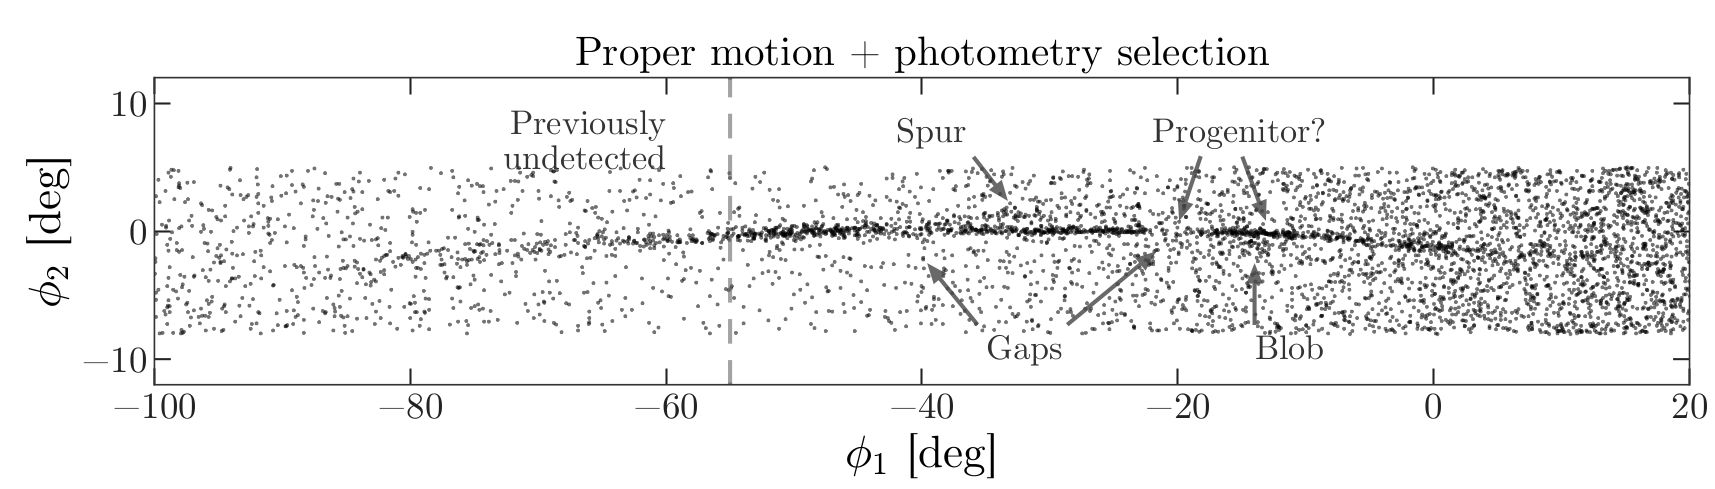

In [7]:
# For example, we can define a selection of stars from the above figure
phi1_min = -55 * u.degree 
phi1_max = -45 * u.degree
phi2_min = -8 * u.degree
phi2_max = 4 * u.degree

In [8]:
def make_rectangle(x1, x2, y1, y2):
    """Return the corners of a rectangle."""
    xs = [x1, x1, x2, x2, x1]
    ys = [y1, y2, y2, y1, y1]
    return xs, ys

In [9]:
phi1_rect, phi2_rect = make_rectangle(
    phi1_min, phi1_max, phi2_min, phi2_max)

In [10]:
phi1_rect, phi2_rect

([<Quantity -55. deg>,
  <Quantity -55. deg>,
  <Quantity -45. deg>,
  <Quantity -45. deg>,
  <Quantity -55. deg>],
 [<Quantity -8. deg>,
  <Quantity 4. deg>,
  <Quantity 4. deg>,
  <Quantity -8. deg>,
  <Quantity -8. deg>])

In [11]:
# Convert coordinates of rectangle from GD-1 to ICRS
corners = SkyCoord(phi1=phi1_rect, phi2=phi2_rect, frame=gd1_frame)
corners_icrs = corners.transform_to('icrs')


In [12]:
corners


<SkyCoord (GD1Koposov10): (phi1, phi2) in deg
    [(-55., -8.), (-55.,  4.), (-45.,  4.), (-45., -8.), (-55., -8.)]>

In [13]:
corners_icrs

<SkyCoord (ICRS): (ra, dec) in deg
    [(146.27533314, 19.26190982), (135.42163944, 25.87738723),
     (141.60264825, 34.3048303 ), (152.81671045, 27.13611254),
     (146.27533314, 19.26190982)]>

## Querying Gaia server using ADQL

Astronomical Data Query Language (ADQL) is similar to Structured Query Language (SQL).

Further details are given in the [Data Carpentries lessons](https://datacarpentry.github.io/astronomy-python/01-query.html).

In [14]:
# This function converts our coordinates above into a string suitable for ADQL
def skycoord_to_string(skycoord):
    """Convert a one-dimensional list of SkyCoord to string for Gaia's query format."""
    corners_list_str = skycoord.to_string()
    corners_single_str = ' '.join(corners_list_str)
    return corners_single_str.replace(' ', ', ')

In [15]:
# Use function to convert our corners
sky_point_list = skycoord_to_string(corners_icrs)
sky_point_list

'146.275, 19.2619, 135.422, 25.8774, 141.603, 34.3048, 152.817, 27.1361, 146.275, 19.2619'

In [16]:
# Create an ADQL statement string in python using some columns and sky_point_list

# Columns we want from Gaia server
columns = 'source_id, ra, dec, pmra, pmdec, parallax'

# Combine with ADQL string
polygon_query_base = """SELECT
{columns}
FROM gaiadr2.gaia_source
WHERE parallax < 1
  AND bp_rp BETWEEN -0.75 AND 2 
  AND 1 = CONTAINS(POINT(ra, dec), 
                   POLYGON({sky_point_list}))
"""

In [17]:
# This is the general form of the ADQL string
print(polygon_query_base)

SELECT
{columns}
FROM gaiadr2.gaia_source
WHERE parallax < 1
  AND bp_rp BETWEEN -0.75 AND 2 
  AND 1 = CONTAINS(POINT(ra, dec), 
                   POLYGON({sky_point_list}))



In [18]:
# This is the formatted form of the ADQL string with 'columns' and 'sky_point_list' variables substituted
# It is what will be used to query the Gaia server.
polygon_query = polygon_query_base.format(columns=columns, 
                          sky_point_list=sky_point_list)
print(polygon_query)

SELECT
source_id, ra, dec, pmra, pmdec, parallax
FROM gaiadr2.gaia_source
WHERE parallax < 1
  AND bp_rp BETWEEN -0.75 AND 2 
  AND 1 = CONTAINS(POINT(ra, dec), 
                   POLYGON(146.275, 19.2619, 135.422, 25.8774, 141.603, 34.3048, 152.817, 27.1361, 146.275, 19.2619))



## Query ESA-Gaia server to get results table

In [19]:
# Run query to get Gaia data using API (info https://astroquery.readthedocs.io/en/latest/gaia/gaia.html)
polygon_job = Gaia.launch_job_async(polygon_query)
print(polygon_job)

INFO: Query finished. [astroquery.utils.tap.core]
<Table length=140339>
   name    dtype    unit                              description                            
--------- ------- -------- ------------------------------------------------------------------
source_id   int64          Unique source identifier (unique within a particular Data Release)
       ra float64      deg                                                    Right ascension
      dec float64      deg                                                        Declination
     pmra float64 mas / yr                         Proper motion in right ascension direction
    pmdec float64 mas / yr                             Proper motion in declination direction
 parallax float64      mas                                                           Parallax
Jobid: a0211f78-7494-11f1-ad14-bc97e148b76b-O
Phase: COMPLETED
Owner: None
Output file: async_20260630150151.vot
Results: None


In [20]:
# Get results data table and calc. number of rows (i.e. number of stars!)
polygon_results = polygon_job.get_results()
len(polygon_results)

140339

In [21]:
# Have a look at results table
polygon_results

source_id,ra,dec,pmra,pmdec,parallax
,deg,deg,mas / yr,mas / yr,mas
int64,float64,float64,float64,float64,float64
638048800917102592,142.56007669245832,22.033684432775416,-0.672377576343034,-3.8363335167995,0.056205598427750095
638310583468648320,142.30092295365523,22.781142193475787,-1.9889337374611793,0.48041412936209477,0.6848157522023909
638097072054542208,142.73924755921135,22.487129309860073,-1.388048783456863,-0.003027615956114732,0.0672815321792452
638246605635491968,142.04380481236907,22.165273723123963,-6.587262426769217,-6.147528335403443,0.9812634578716778
638292338447967104,142.64475145097504,22.67497702510293,-7.153377463930616,-10.095803184951293,0.7646885861537246
638276915220185472,141.892025875557,22.54117572329128,4.730545931591898,-7.75658403031426,-1.1438322656303779
638068763925078784,142.76866997992656,22.0612819524861,-9.990115115295367,-9.80821644635322,0.7567065501984894
638018869289742336,143.02874873867873,22.029690700582538,-0.9770718336037447,-8.478335401017246,0.41060118548030816


In [22]:
# Save results
filename = 'gd1_results.fits'
polygon_results.write(filename, overwrite=True)

### Plotting the stars using data in results table

In [23]:
%matplotlib inline

Text(0, 0.5, 'dec (degree ICRS)')

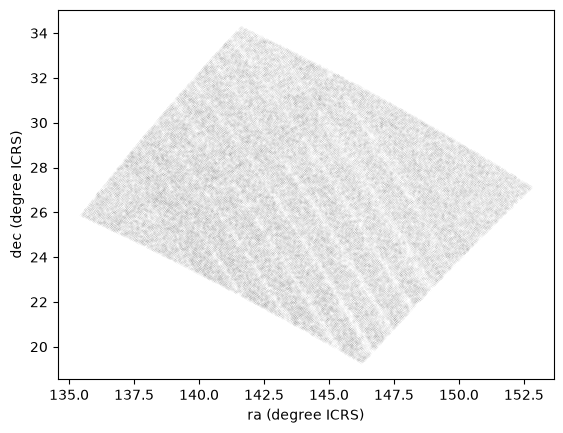

In [24]:
# Scatterplot of stars in ICRS coordinates
x = polygon_results['ra']
y = polygon_results['dec']
plt.plot(x, y, 'ko', markersize=0.05, alpha=0.2)

plt.xlabel('ra (degree ICRS)')
plt.ylabel('dec (degree ICRS)')

### Why the stripes?

https://www.cosmos.esa.int/web/gaia/scanning-law


### Transform from IC to GD-1 coords

In [25]:
distance = 8 * u.kpc
radial_velocity= 0 * u.km/u.s

skycoord = SkyCoord(ra=polygon_results['ra'], 
                    dec=polygon_results['dec'],
                    pm_ra_cosdec=polygon_results['pmra'],
                    pm_dec=polygon_results['pmdec'], 
                    distance=distance, 
                    radial_velocity=radial_velocity)

In [26]:
transformed = skycoord.transform_to(gd1_frame)

### Add a correction to proper motions 

"The next step is to correct the proper motion measurements for the effect of the motion of our solar system around the Galactic center."

https://datacarpentry.github.io/astronomy-python/03-transform.html#reflex-correction

In [27]:
from reflex import reflex_correct
skycoord_gd1 = reflex_correct(transformed)
x = skycoord_gd1.phi1
y = skycoord_gd1.phi2


Text(0, 0.5, 'phi2 (degree GD1)')

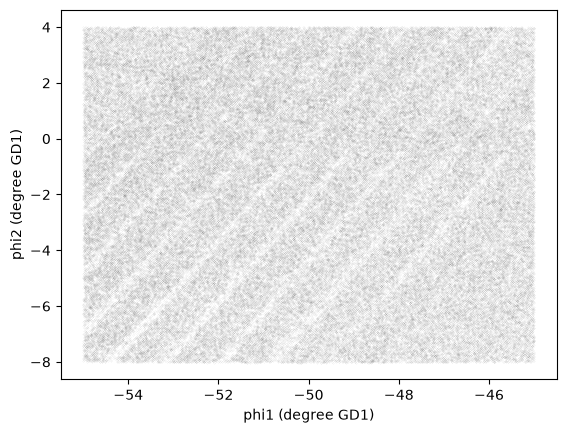

In [28]:
# Plot transformed coords
plt.plot(x, y, 'ko', markersize=0.1, alpha=0.2)

plt.xlabel('phi1 (degree GD1)')
plt.ylabel('phi2 (degree GD1)')

### Converting Astropy to Pandas data frame

Pandas makes many data processing steps easier, but note that it does not handle the units from astropy

In [29]:
results_df = polygon_results.to_pandas()
results_df.shape

(140339, 6)

In [30]:
results_df.head()

,source_id,ra,dec,pmra,pmdec,parallax
0,638048800917102592,142.560077,22.033684,-0.672378,-3.836334,0.056206
1,638310583468648320,142.300923,22.781142,-1.988934,0.480414,0.684816
2,638097072054542208,142.739248,22.487129,-1.388049,-0.003028,0.067282
3,638246605635491968,142.043805,22.165274,-6.587262,-6.147528,0.981263
4,638292338447967104,142.644751,22.674977,-7.153377,-10.095803,0.764689


In [31]:
# Join GD-1 coords and corrected motions to data frame
results_df['phi1'] = skycoord_gd1.phi1.value
results_df['phi2'] = skycoord_gd1.phi2.value
results_df['pm_phi1'] = skycoord_gd1.pm_phi1_cosphi2.value
results_df['pm_phi2'] = skycoord_gd1.pm_phi2.value
results_df.shape

(140339, 10)

In [32]:
results_df.head()

,source_id,ra,dec,pmra,pmdec,parallax,phi1,phi2,pm_phi1,pm_phi2
0,638048800917102592,142.560077,22.033684,-0.672378,-3.836334,0.056206,-54.706521,-3.563735,1.862174,1.193371
1,638310583468648320,142.300923,22.781142,-1.988934,0.480414,0.684816,-54.221217,-2.946211,4.715486,4.733068
2,638097072054542208,142.739248,22.487129,-1.388049,-0.003028,0.067282,-54.237389,-3.446066,4.647759,3.943169
3,638246605635491968,142.043805,22.165274,-6.587262,-6.147528,0.981263,-54.865532,-3.093706,-3.369103,4.840074
4,638292338447967104,142.644751,22.674977,-7.153377,-10.095803,0.764689,-54.130965,-3.268268,-6.935874,3.044143


## Function to wrap up transformation steps

In [33]:
def make_dataframe(table):
    """Transform and astropy table with coords in ICRS, convert to pandas dataframe with GD-1 coordinates.
    
    table: Astropy Table
    
    returns: pandas DataFrame
    """
    #Create a SkyCoord object with the coordinates and proper motions
    # in the input table
    skycoord = SkyCoord(
               ra=table['ra'], 
               dec=table['dec'],
               pm_ra_cosdec=table['pmra'],
               pm_dec=table['pmdec'], 
               distance=8*u.kpc, 
               radial_velocity=0*u.km/u.s)

    # Define the GD-1 reference frame
    gd1_frame = GD1Koposov10()

    # Transform input coordinates to the GD-1 reference frame
    transformed = skycoord.transform_to(gd1_frame)

    # Correct GD-1 coordinates for solar system motion around galactic center
    skycoord_gd1 = reflex_correct(transformed)

    # Create DataFrame
    df = table.to_pandas()

    # Add GD-1 reference frame columns for coordinates and proper motions
    df['phi1'] = skycoord_gd1.phi1.value
    df['phi2'] = skycoord_gd1.phi2.value
    df['pm_phi1'] = skycoord_gd1.pm_phi1_cosphi2.value
    df['pm_phi2'] = skycoord_gd1.pm_phi2.value

    return df

In [34]:
# Here's how to use above function...
results_df = make_dataframe(polygon_results)

In [35]:
filename = 'gd1_data.hdf'

results_df.to_hdf(filename, key='results_df', mode='w')

### Using the Pandas data frame

In [36]:
# Useful stats function available in Pandas. 
# Note calculating stats can be meaningless on some columns (e.g. source_id) 
results_df.describe()

,source_id,ra,dec,pmra,pmdec,parallax,phi1,phi2,pm_phi1,pm_phi2
count,1.403390e+05,140339.000000,140339.000000,140339.000000,140339.000000,140339.000000,140339.000000,140339.000000,140339.000000,140339.000000
mean,6.792399e+17,143.823122,26.780285,-2.484404,-6.100777,0.179492,-50.091158,-1.803301,-0.868963,1.409208
std,3.792177e+16,3.697850,3.052592,5.913939,7.202047,0.759590,2.892344,3.444398,6.657714,6.518615
min,6.214900e+17,135.425699,19.286617,-106.755260,-138.065163,-15.287602,-54.999989,-8.029159,-115.275637,-161.150142
25%,6.443517e+17,140.967966,24.592490,-5.038789,-8.341561,-0.035981,-52.602952,-4.750426,-2.948723,-1.107128
50%,6.888060e+17,143.734409,26.746261,-1.834943,-4.689596,0.362708,-50.147362,-1.671502,0.585037,1.987149
75%,6.976579e+17,146.607350,28.990500,0.452893,-1.937809,0.657637,-47.593279,1.160514,3.001768,4.628965
max,7.974418e+17,152.777393,34.285481,104.319923,20.981070,0.999957,-44.999985,4.014609,39.802471,79.275199


### Plot proper motions

Text(0, 0.5, 'Proper motion phi2 (mas/yr GD1 frame)')

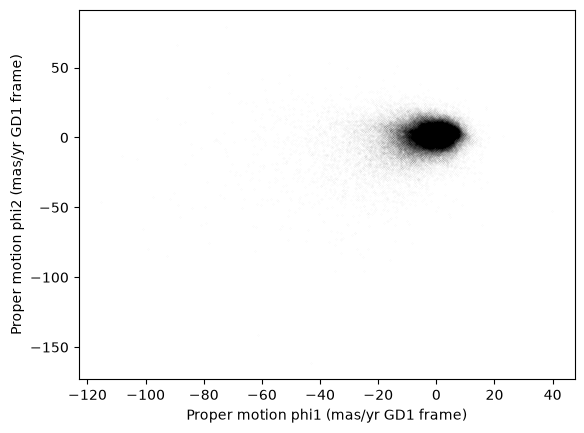

In [37]:
x = results_df['pm_phi1']
y = results_df['pm_phi2']
plt.plot(x, y, 'ko', markersize=0.1, alpha=0.1)
    
plt.xlabel('Proper motion phi1 (mas/yr GD1 frame)')
plt.ylabel('Proper motion phi2 (mas/yr GD1 frame)')

### Continuation

If you wish to continue with this, would suggest refer to main Data Carpentries pages here:

https://datacarpentry.github.io/astronomy-python/04-motion.html

